In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as F
from torchvision import transforms
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline, DiffusionPipeline
from diffusers.optimization import get_scheduler
from torchvision.models import vgg16  
from peft import LoraConfig
from tqdm import tqdm
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
# 폴더 경로 설정
dataset_folder = r"C:\Users\Hyunyoung\datasets_diffusion_test_arch"
input_image_dir = os.path.join(dataset_folder, "input")
target_image_dir = os.path.join(dataset_folder, "output")

# 이미지 변환 설정 (전처리)
IMG_SIZE = 256
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),  
    transforms.RandomVerticalFlip(),  
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # (0,1)->(-1,1) 범위로 정규화
])

# 데이터셋 정의 (로컬 디렉토리에서 이미지를 로드)
class ImagePairDataset(torch.utils.data.Dataset):
    def __init__(self, input_dir, target_dir, file_list, transform=None):  
        self.input_dir = input_dir
        self.target_dir = target_dir
        self.file_list = file_list  
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        # input과 output의 파일 확장자는 각각 png와 jpg라고 가정
        input_image_path = os.path.join(self.input_dir, filename + ".png")
        target_image_path = os.path.join(self.target_dir, filename + ".jpg")

        # 이미지 로드
        input_image = Image.open(input_image_path).convert("RGB")
        target_image = Image.open(target_image_path).convert("RGB")

        # 이미지 전처리
        if self.transform:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)

        return {"input_image": input_image, "target_image": target_image}


# 확장자를 제거한 파일 이름 목록 생성
input_filenames = {os.path.splitext(f)[0] for f in os.listdir(input_image_dir)}  # 확장자 제거
target_filenames = {os.path.splitext(f)[0] for f in os.listdir(target_image_dir)}  # 확장자 제거


# print("Input 폴더 파일 목록:")
# print(input_filenames)
# print("\nOutput 폴더 파일 목록:")
# print(target_filenames)

# input과 output 폴더에 모두 존재하는 파일만 매칭
common_filenames = list(set(input_filenames).intersection(set(target_filenames)))
common_filenames.sort()  # 파일 이름 정렬

# 매칭된 파일 목록 출력
print("\n매칭된 파일 목록:")
print(common_filenames)

# 파일이 없으면 오류 메시지 출력
if len(common_filenames) == 0:
    print("Error: input 폴더와 output 폴더에 이름이 같은 파일이 없습니다.")
else:
    # 확장자는 ImagePairDataset에서 처리하므로, 파일 이름만 저장
    common_filenames = [f for f in common_filenames]

# Train/Test 데이터를 80/20 비율로 나눔
train_filenames, eval_filenames = train_test_split(common_filenames, test_size=0.2, random_state=42)

# Train/Validation 데이터셋 생성
train_dataset = ImagePairDataset(input_image_dir, target_image_dir, train_filenames, transform=train_transforms)
eval_dataset = ImagePairDataset(input_image_dir, target_image_dir, eval_filenames, transform=train_transforms)

# DataLoader 설정
BATCH_SIZE = 2
NUM_WORKERS = 0

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

eval_dataloader = torch.utils.data.DataLoader(
    eval_dataset,
    shuffle=False,  # 검증 데이터는 순서를 유지합니다.
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)


매칭된 파일 목록:
['cmp_b0001', 'cmp_b0002', 'cmp_b0003', 'cmp_b0004', 'cmp_b0005', 'cmp_b0006', 'cmp_b0007', 'cmp_b0008', 'cmp_b0009', 'cmp_b0010', 'cmp_b0011', 'cmp_b0012', 'cmp_b0013', 'cmp_b0014', 'cmp_b0015', 'cmp_b0016', 'cmp_b0017', 'cmp_b0018', 'cmp_b0019', 'cmp_b0020', 'cmp_b0021', 'cmp_b0022', 'cmp_b0023', 'cmp_b0024', 'cmp_b0025', 'cmp_b0026', 'cmp_b0027', 'cmp_b0028', 'cmp_b0029', 'cmp_b0030', 'cmp_b0031', 'cmp_b0032', 'cmp_b0033', 'cmp_b0034', 'cmp_b0035', 'cmp_b0036', 'cmp_b0037', 'cmp_b0038', 'cmp_b0039', 'cmp_b0040', 'cmp_b0041', 'cmp_b0042', 'cmp_b0043', 'cmp_b0044', 'cmp_b0045', 'cmp_b0046', 'cmp_b0047', 'cmp_b0048', 'cmp_b0049', 'cmp_b0050', 'cmp_b0051', 'cmp_b0052', 'cmp_b0053', 'cmp_b0054', 'cmp_b0055', 'cmp_b0056', 'cmp_b0057', 'cmp_b0058', 'cmp_b0059', 'cmp_b0060', 'cmp_b0061', 'cmp_b0062', 'cmp_b0063', 'cmp_b0064', 'cmp_b0065', 'cmp_b0066', 'cmp_b0067', 'cmp_b0068', 'cmp_b0069', 'cmp_b0070', 'cmp_b0071', 'cmp_b0072', 'cmp_b0073', 'cmp_b0074', 'cmp_b0075', 'cmp_b0076',

In [18]:
# 모델 설정
PRE_TRAINED_MODEL_NAME = "runwayml/stable-diffusion-v1-5"
noise_scheduler = DDPMScheduler.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="scheduler")
tokenizer = CLIPTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="unet")

# 장치 설정
text_encoder.to(device)
vae.to(device)
unet.to(device)

# VGG 모델 설정 (피처 추출용)
vgg = vgg16(pretrained=True).features.to(device).eval()  

# LoRA 설정
LORA_RANK = 16
unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

# LoRA 적용
unet.add_adapter(unet_lora_config)

# Optimizer 설정
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, unet.parameters()),  # 학습 가능한 파라미터만
    lr=5e-5
)

EPOCHS = 20
# lr_scheduler 설정
lr_scheduler = get_scheduler(
    'linear',  # linear는 학습률을 선형적으로 감소
    optimizer=optimizer,
    num_warmup_steps=500,  # 초기 warm-up 단계
    num_training_steps=EPOCHS * len(train_dataloader)  # 전체 학습 스텝 수
)

def perceptual_loss(img1, img2):
    if img1.shape[1] != 3 or img2.shape[1] != 3:  # 수정됨: VGG는 3채널 RGB 이미지를 기대
        raise ValueError("Input to perceptual_loss must have 3 channels (RGB).")
    features1 = vgg(img1)
    features2 = vgg(img2)
    return F.mse_loss(features1, features2)

In [19]:
# 학습 루프
train_losses = []
eval_losses = []  
scaler = torch.amp.GradScaler('cuda')

for epoch in range(EPOCHS):
    unet.train()
    
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(progress_bar):
        input_images = batch["input_image"].to(device)
        target_images = batch["target_image"].to(device)

        # 캐시 비우기
        torch.cuda.empty_cache()

        # VAE로 입력 이미지 인코딩
        latents = vae.encode(input_images).latent_dist.sample()
        latents = latents * vae.config.scaling_factor

        # 타겟 이미지도 VAE로 인코딩하여 잠재 벡터로 변환 
        target_latents = vae.encode(target_images).latent_dist.sample()  
        target_latents = target_latents * vae.config.scaling_factor  

        # 노이즈 추가
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device)
        timesteps = timesteps.long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 텍스트 입력 추가
        text_input = tokenizer(
            ["Abstract blueprint-style input transforms into a realistic classical building output."] * BATCH_SIZE, 
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=tokenizer.model_max_length
        )
        encoder_hidden_states = text_encoder(text_input.input_ids.to(device))[0]

        # U-Net으로 노이즈 예측 (텍스트 인코딩 제거)
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample

            # 텐서 다운샘플링
            model_pred = torch.nn.functional.interpolate(model_pred, scale_factor=0.5)
            target_latents = torch.nn.functional.interpolate(target_latents, scale_factor=0.5)

            #vae.enable_slicing()

            # vae.decode()에서 필요한 텐서만 추출 (첫 번째 값)
            decoded_pred = vae.decode(model_pred, return_dict=False)[0] 
            decoded_target = vae.decode(target_latents, return_dict=False)[0]  

            # 크기 맞추기: 필요한 경우 interpolate 사용
            if model_pred.shape != noise.shape:
                noise = torch.nn.functional.interpolate(noise, size=model_pred.shape[2:])
                
            image_loss = F.mse_loss(decoded_pred, decoded_target)
            perc_loss = perceptual_loss(decoded_pred, decoded_target)  
            noise_loss = F.mse_loss(model_pred.float(), noise.float())  
            loss = noise_loss + image_loss + 0.1 * perc_loss  
            # loss = noise_loss + image_loss

        # 손실 기록 및 학습
        train_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        lr_scheduler.step()

        progress_bar.set_postfix({'loss': loss.item()})

    # 평균 손실 출력
    avg_loss = sum(train_losses[-100:]) / len(train_losses[-100:])
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_loss:.4f}")

    # 매 Epoch마다 학습률 확인
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning rate after epoch {epoch+1}: {current_lr:.8f}")

    # # 검증 루프 추가
    # unet.eval()
    # eval_loss = 0
    # with torch.no_grad():
    #     for batch in tqdm(eval_dataloader, desc="Evaluation"):
    #         input_images = batch["input_image"].to(device)
    #         target_images = batch["target_image"].to(device)

    #         # 캐시 비우기
    #         torch.cuda.empty_cache()

    #         latents = vae.encode(input_images).latent_dist.sample()
    #         latents = latents * vae.config.scaling_factor

    #         # 타겟 이미지 인코딩
    #         target_latents = vae.encode(target_images).latent_dist.sample()
    #         target_latents = target_latents * vae.config.scaling_factor

    #         # 텍스트 입력 추가
    #         text_input = tokenizer(
    #             ["Abstract blueprint-style input transforms into a realistic classical building output."] * BATCH_SIZE,  
    #             return_tensors="pt",
    #             padding="max_length",
    #             truncation=True,
    #             max_length=tokenizer.model_max_length
    #         )
    #         encoder_hidden_states = text_encoder(text_input.input_ids.to(device))[0]

            
    #         with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
    #             model_pred = unet(latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample  
                
    #             # vae.enable_slicing()

    #             # vae.decode()에서 필요한 텐서만 추출 
    #             decoded_pred = vae.decode(model_pred, return_dict=False)[0]  
    #             decoded_target = vae.decode(target_latents, return_dict=False)[0]  

    #             # 크기 맞추기: 필요한 경우 interpolate 
    #             if model_pred.shape != noise.shape:
    #                 noise = torch.nn.functional.interpolate(noise, size=model_pred.shape[2:])

    #             image_loss = F.mse_loss(decoded_pred, decoded_target) 
    #             perc_loss = perceptual_loss(decoded_pred, decoded_target) 
    #             loss = image_loss + 0.1 * perc_loss
    #             # loss = image_loss

    #         eval_loss += loss.item()

    # eval_loss /= len(eval_dataloader)
    # eval_losses.append(eval_loss)
    # print(f"Epoch [{epoch+1}/{EPOCHS}], Eval Loss: {eval_loss:.4f}")

Epoch 1/20: 100%|██████████| 145/145 [50:42<00:00, 20.98s/it, loss=0.123]  


Epoch [1/20], Train Loss: 0.1164
Learning rate after epoch 1: 0.00001450


Epoch 2/20: 100%|██████████| 145/145 [47:07<00:00, 19.50s/it, loss=0.156]  


Epoch [2/20], Train Loss: 0.1030
Learning rate after epoch 2: 0.00002900


Epoch 3/20: 100%|██████████| 145/145 [52:33<00:00, 21.75s/it, loss=0.0722]


...

Epoch [18/20], Train Loss: 0.0825
Learning rate after epoch 18: 0.00000604


Epoch 19/20: 100%|██████████| 145/145 [11:57<00:00,  4.95s/it, loss=0.0805]


Epoch [19/20], Train Loss: 0.0886
Learning rate after epoch 19: 0.00000302


Epoch 20/20: 100%|██████████| 145/145 [13:39<00:00,  5.65s/it, loss=0.0995]

Epoch [20/20], Train Loss: 0.0940
Learning rate after epoch 20: 0.00000000


In [20]:
# 모델 저장
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)
pipeline.save_pretrained("./fine_tuned_model(2)")

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 14.24it/s]


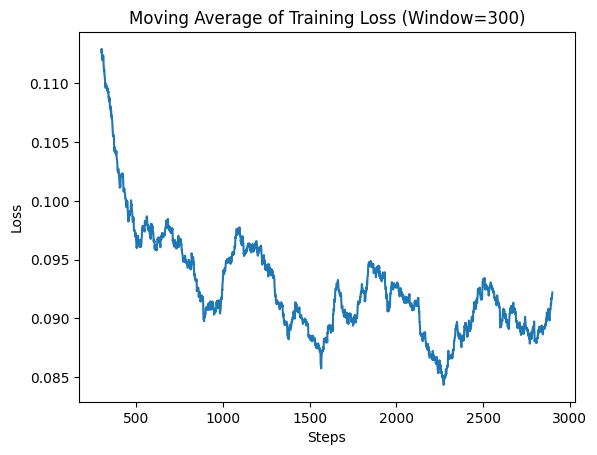

In [21]:
# 손실 추이를 저장하는 부분
losses_sr = pd.Series(train_losses)
loss_mv = losses_sr.rolling(window=300).mean()

# 손실 이동 평균 그래프 그리기
plt.plot(loss_mv)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Moving Average of Training Loss (Window=300)')
plt.show()

In [22]:
# 이미지 파일을 열고 텐서로 변환하는 함수
def load_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0).to(device)

# 이미지 경로 설정
input_image_path = r"C:\Users\Hyunyoung\datasets_diffusion_test_arch\test_input.png" 

# 이미지 로드 및 전처리
transform = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # (-1, 1) 범위로 정규화
])

# 입력 이미지를 텐서로 변환
input_image_tensor = load_image(input_image_path, transform)

# Stable Diffusion Pipeline 설정 및 모델 연결
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,  # 미세 조정된 UNet
)

pipeline.to(device)

# output 이미지를 저장할 새로운 폴더 경로 생성
output_image_dir = os.path.join(dataset_folder, "generated_output")  
os.makedirs(output_image_dir, exist_ok=True)  # 폴더가 없을 경우 생성

# 결과 이미지를 저장하는 함수
def save_generated_image(image, filename, output_dir=output_image_dir): 
    # 확장자가 없으면 기본 확장자 .png를 추가
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):  
        filename += ".png"
    
    save_path = os.path.join(output_dir, filename)
    image.save(save_path)

# 이미지를 VAE로 인코딩하여 잠재 벡터 생성
with torch.no_grad():
    latents = vae.encode(input_image_tensor).latent_dist.sample()  # 이미지를 잠재 벡터로 인코딩
    latents = latents * vae.config.scaling_factor  # VAE scaling factor 적용


# 이미지 생성 및 저장 (inference)
lora_scale = 0.9  # LoRA 적용 비율
pipeline_output = pipeline(
    prompt=["Abstract blueprint-style input transforms into a realistic classical building output."],  
    latents=latents, 
    num_inference_steps=20,  
    cross_attention_kwargs={"scale": lora_scale},  
    generator=torch.manual_seed(101)
)

# 생성된 이미지를 저장
generated_image = pipeline_output.images[0]
filename = "generated_image.png"  # 저장할 파일 이름 지정
save_generated_image(generated_image, filename)  # 이미지 저장

100%|██████████| 20/20 [00:21<00:00,  1.05s/it]
